In [1]:
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter
import pandas as pd


In [37]:
from datetime import datetime
FIG_DIR = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed/figures")
td = datetime.today().strftime("%m_%d_%y")
fig_path = FIG_DIR / td

# 2. Create the directory (this returns None, so we do it on its own line)
fig_path.mkdir(parents=True, exist_ok=True)

In [2]:
import re
import numpy as np
from pathlib import Path

major_path = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed")

mapping = {
    'F1': {'0': 'No_motion', '1': 'Motion'},
    'F2': {'0': 'Motion', '1': 'No_motion', '2': 'Anesthesia'},
    'F3': {'0': 'Anesthesia', '1': 'No_motion', '2': 'Motion'},
    'F4': {'0': 'Motion', '1': 'No_motion', '2': 'Motion', '3': 'No_motion', '4': 'Anesthesia'}
}

def list_plane0_folders(root: Path):
    """Return list of dicts: fov, suffix, state, plane0 path."""
    out = []
    for plane0 in root.rglob("plane0"):
        if not plane0.is_dir():
            continue

        parent = plane0.parent.name               # e.g. F4_3
        fov = plane0.parent.parent.name           # e.g. F4

        m = re.match(r"^(F\d+)_(\d+)$", parent)
        if not m:
            continue
        fov2, suffix = m.group(1), m.group(2)
        if fov != fov2:
            continue

        state = mapping.get(fov, {}).get(suffix, "UNKNOWN")
        out.append({"fov": fov, "suffix": suffix, "state": state, "plane0": plane0})

    # stable ordering
    out.sort(key=lambda d: (d["fov"], int(d["suffix"])))
    return out

datasets = list_plane0_folders(major_path)
print("Found plane0 folders:", len(datasets))
for d in datasets:
    print(f"{d['fov']}_{d['suffix']}  {d['state']:>10}   {d['plane0']}")


Found plane0 folders: 13
F1_0   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_0\plane0
F1_1      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F1\F1_1\plane0
F2_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_0\plane0
F2_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_1\plane0
F2_2  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F2\F2_2\plane0
F3_0  Anesthesia   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_0\plane0
F3_1   No_motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_1\plane0
F3_2      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc\working on data\processed\F3\F3_2\plane0
F4_0      Motion   C:\Users\gp00062\OneDrive - WVUM and HSC\WVU postdoc

In [3]:
import numpy as np
from pathlib import Path

def safe_load(path: Path):
    return np.load(path, allow_pickle=True) if path.exists() else None

# state string used in filenames matches your normalized labels:
# "No_motion", "Motion", "Anesthesia"
for d in datasets:
    s = d["state"]  # already normalized
    p0 = d["plane0"]

    d["adj_raw_path"] = p0 / f"adjacency_{s}_deco.npy"

    d["adj_raw"] = safe_load(d["adj_raw_path"])

print("RAW loaded:", sum(d["adj_raw"] is not None for d in datasets), "/", len(datasets))

# show a few
for d in datasets[:6]:
    print(d["fov"], d["suffix"], d["state"],
          "| raw:", d["adj_raw_path"].name, "->", None if d["adj_raw"] is None else d["adj_raw"].shape)

RAW loaded: 13 / 13
F1 0 No_motion | raw: adjacency_No_motion_deco.npy -> (406, 406)
F1 1 Motion | raw: adjacency_Motion_deco.npy -> (528, 528)
F2 0 Motion | raw: adjacency_Motion_deco.npy -> (496, 496)
F2 1 No_motion | raw: adjacency_No_motion_deco.npy -> (418, 418)
F2 2 Anesthesia | raw: adjacency_Anesthesia_deco.npy -> (320, 320)
F3 0 Anesthesia | raw: adjacency_Anesthesia_deco.npy -> (213, 213)


#### Get the list of hub for each state

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import math
from pathlib import Path

# ----------------------------
# Variants (same logic as yours)
# ----------------------------
def build_network_variants(W_signed: np.ndarray):
    W_signed = np.asarray(W_signed, dtype=float)
    W_signed = (W_signed + W_signed.T) / 2.0
    np.fill_diagonal(W_signed, 0.0)

    return {
        "combined": np.abs(W_signed),
        "positive": np.where(W_signed > 0, W_signed, 0.0),
        "negative": np.where(W_signed < 0, -W_signed, 0.0),
    }

# ----------------------------
# Hub metrics + hub selection
# ----------------------------
def compute_hubs_for_matrix(W_nonneg: np.ndarray, top_frac=0.10):
    """
    W_nonneg: NxN non-negative weighted adjacency (undirected).
    Returns:
      node_metrics_df (all nodes),
      hub_nodes (sorted list),
      top_sets (dict of sets for each metric)
    """
    G = nx.from_numpy_array(W_nonneg)  # undirected weighted graph

    n_nodes = G.number_of_nodes()
    k = max(1, math.ceil(top_frac * n_nodes))

    # Strength (weighted degree)
    strength = dict(G.degree(weight="weight"))

    # Distances for betweenness: distance = 1/weight for w>0
    # nx.betweenness_centrality ignores absent edges; we set distance on existing edges only
    for u, v, d in G.edges(data=True):
        w = float(d.get("weight", 0.0))
        d["distance"] = (1.0 / w) if w > 0 else np.inf

    betw = nx.betweenness_centrality(G, weight="distance", normalized=True)

    # Eigenvector centrality (weighted)
    try:
        eig = nx.eigenvector_centrality_numpy(G, weight="weight")
    except Exception:
        eig = nx.eigenvector_centrality(G, weight="weight", max_iter=2000)

    def top_k(cent_dict):
        return {
            node for node, _ in sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:k]
        }

    top_strength = top_k(strength)
    top_betw     = top_k(betw)
    top_eig      = top_k(eig)

    hubs = top_strength & top_betw & top_eig

    # node-level table
    df_nodes = pd.DataFrame({
        "node": np.arange(n_nodes, dtype=int),
        "strength": [strength.get(i, 0.0) for i in range(n_nodes)],
        "betweenness": [betw.get(i, 0.0) for i in range(n_nodes)],
        "eigenvector": [eig.get(i, 0.0) for i in range(n_nodes)],
        "is_top_strength": [i in top_strength for i in range(n_nodes)],
        "is_top_betweenness": [i in top_betw for i in range(n_nodes)],
        "is_top_eigenvector": [i in top_eig for i in range(n_nodes)],
        "is_hub": [i in hubs for i in range(n_nodes)],
    })

    top_sets = {
        "top_strength": top_strength,
        "top_betweenness": top_betw,
        "top_eigenvector": top_eig,
    }

    return df_nodes, sorted(hubs), top_sets, k

# ----------------------------
# Batch across your `datasets`
# ----------------------------
def batch_hub_analysis(datasets, top_frac=0.10, net_types=("combined", "positive", "negative")):
    node_rows = []
    hub_rows = []
    summary_rows = []

    for d in datasets:
        W_signed = d.get("adj_raw", None)
        if W_signed is None:
            continue

        variants = build_network_variants(W_signed)

        for net_type in net_types:
            W = variants[net_type]
            df_nodes, hub_nodes, top_sets, k = compute_hubs_for_matrix(W, top_frac=top_frac)

            # annotate node-level table with sample info
            df_nodes.insert(0, "net_type", net_type)
            df_nodes.insert(0, "state", d["state"])
            df_nodes.insert(0, "suffix", int(d["suffix"]))
            df_nodes.insert(0, "fov", d["fov"])

            node_rows.append(df_nodes)

            # hubs-only table
            for node in hub_nodes:
                hub_rows.append({
                    "fov": d["fov"],
                    "suffix": int(d["suffix"]),
                    "state": d["state"],
                    "net_type": net_type,
                    "node": int(node),
                })

            n_nodes = W.shape[0]
            n_hubs = len(hub_nodes)
            summary_rows.append({
                "fov": d["fov"],
                "suffix": int(d["suffix"]),
                "state": d["state"],
                "net_type": net_type,
                "N": int(n_nodes),
                "top_k": int(k),
                "n_hubs": int(n_hubs),
                "hub_fraction": float(n_hubs / n_nodes) if n_nodes > 0 else np.nan,
            })

            print(f"{d['fov']}_{d['suffix']} {d['state']} | {net_type}: "
                  f"N={n_nodes}, top_k={k}, hubs={n_hubs}")

    df_nodes_all = pd.concat(node_rows, ignore_index=True) if node_rows else pd.DataFrame()
    df_hubs_all = pd.DataFrame(hub_rows)
    df_summary = pd.DataFrame(summary_rows)

    return df_nodes_all, df_hubs_all, df_summary

# Run
df_nodes_all, df_hubs_all, df_hub_summary = batch_hub_analysis(datasets, top_frac=0.10)

# Optional: make state labels pretty if you haven't already
df_nodes_all["state"] = df_nodes_all["state"].astype(str).str.replace("_", " ", regex=False)
df_hubs_all["state"]  = df_hubs_all["state"].astype(str).str.replace("_", " ", regex=False)
df_hub_summary["state"] = df_hub_summary["state"].astype(str).str.replace("_", " ", regex=False)

print(df_hub_summary.head())

F1_0 No_motion | combined: N=406, top_k=41, hubs=25
F1_0 No_motion | positive: N=406, top_k=41, hubs=20
F1_0 No_motion | negative: N=406, top_k=41, hubs=30
F1_1 Motion | combined: N=528, top_k=53, hubs=42
F1_1 Motion | positive: N=528, top_k=53, hubs=28
F1_1 Motion | negative: N=528, top_k=53, hubs=36
F2_0 Motion | combined: N=496, top_k=50, hubs=40
F2_0 Motion | positive: N=496, top_k=50, hubs=31
F2_0 Motion | negative: N=496, top_k=50, hubs=35
F2_1 No_motion | combined: N=418, top_k=42, hubs=25
F2_1 No_motion | positive: N=418, top_k=42, hubs=12
F2_1 No_motion | negative: N=418, top_k=42, hubs=32
F2_2 Anesthesia | combined: N=320, top_k=32, hubs=19
F2_2 Anesthesia | positive: N=320, top_k=32, hubs=8
F2_2 Anesthesia | negative: N=320, top_k=32, hubs=25
F3_0 Anesthesia | combined: N=213, top_k=22, hubs=8
F3_0 Anesthesia | positive: N=213, top_k=22, hubs=11
F3_0 Anesthesia | negative: N=213, top_k=22, hubs=12
F3_1 No_motion | combined: N=235, top_k=24, hubs=13
F3_1 No_motion | positive:

In [5]:
#### We save these hub neurons
out_dir = Path(r"C:/Users/gp00062/OneDrive - WVUM and HSC/WVU postdoc/working on data/processed/hub_results")
out_dir.mkdir(exist_ok=True)

df_nodes_all.to_parquet(out_dir / "hub_node_metrics.parquet", index=False)
df_hubs_all.to_parquet(out_dir / "hub_nodes_only.parquet", index=False)
df_hub_summary.to_parquet(out_dir / "hub_summary.parquet", index=False)

#### Hub Ratio across states

In [11]:
df_nodes_all.groupby(["state", "net_type"]).apply(
    lambda x: x["strength"].std()
)

C:\Users\gp00062\AppData\Local\Temp\ipykernel_25180\2098827974.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nodes_all.groupby(["state", "net_type"]).apply(


state       net_type
Anesthesia  combined    21.124540
            negative     9.391747
            positive    15.685178
Motion      combined    31.580318
            negative    15.914015
            positive    20.987752
No motion   combined    29.170125
            negative    10.171270
            positive    24.914393
dtype: float64

In [12]:
df_nodes_all.groupby(["state", "net_type"]).apply(
    lambda x: x["betweenness"].std()
)

C:\Users\gp00062\AppData\Local\Temp\ipykernel_25180\2256654922.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nodes_all.groupby(["state", "net_type"]).apply(


state       net_type
Anesthesia  combined    0.003940
            negative    0.010484
            positive    0.003472
Motion      combined    0.002411
            negative    0.007823
            positive    0.002015
No motion   combined    0.003104
            negative    0.008622
            positive    0.002341
dtype: float64

In [13]:
df_nodes_all.groupby(["state","net_type"]).apply(
    lambda x: x[["strength","betweenness","eigenvector"]].corr()
)

C:\Users\gp00062\AppData\Local\Temp\ipykernel_25180\3750758770.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_nodes_all.groupby(["state","net_type"]).apply(


strength  betweenness  eigenvector
state      net_type                                                
Anesthesia combined strength     1.000000     0.572070     0.780464
                    betweenness  0.572070     1.000000     0.617440
                    eigenvector  0.780464     0.617440     1.000000
           negative strength     1.000000     0.660318     0.647959
                    betweenness  0.660318     1.000000     0.829341
                    eigenvector  0.647959     0.829341     1.000000
           positive strength     1.000000     0.609728     0.861245
                    betweenness  0.609728     1.000000     0.560203
                    eigenvector  0.861245     0.560203     1.000000
Motion     combined strength     1.000000     0.475748     0.653602
                    betweenness  0.475748     1.000000     0.827214
                    eigenvector  0.653602     0.827214     1.000000
           negative strength     1.000000     0.680992     0.833865
                    betweenness  0.680992     1.000000     0.741371
                    eigenvector  0.833865     0.741371     1.000000
           positive strength     1.000000     0.237647     0.571803
                    betweenness  0.237647     1.000000     0.608267
                    eigenvector  0.571803     0.608267     1.000000
No motion  combined strength     1.000000     0.509022     0.732662
                    betweenness  0.509022     1.000000     0.645613
                    eigenvector  0.732662     0.645613     1.000000
           negative strength     1.000000     0.757880     0.753269
                    betweenness  0.757880     1.000000     0.804088
                    eigenvector  0.753269     0.804088     1.000000
           positive strength     1.000000     0.376352     0.728619
                    betweenness  0.376352     1.000000     0.528104
                    eigenvector  0.728619     0.528104     1.000000

In [6]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

In [10]:
df_hub_ratio = df_hub_summary.copy()
df_hub_ratio.to_excel('hub_ratio.xlsx')

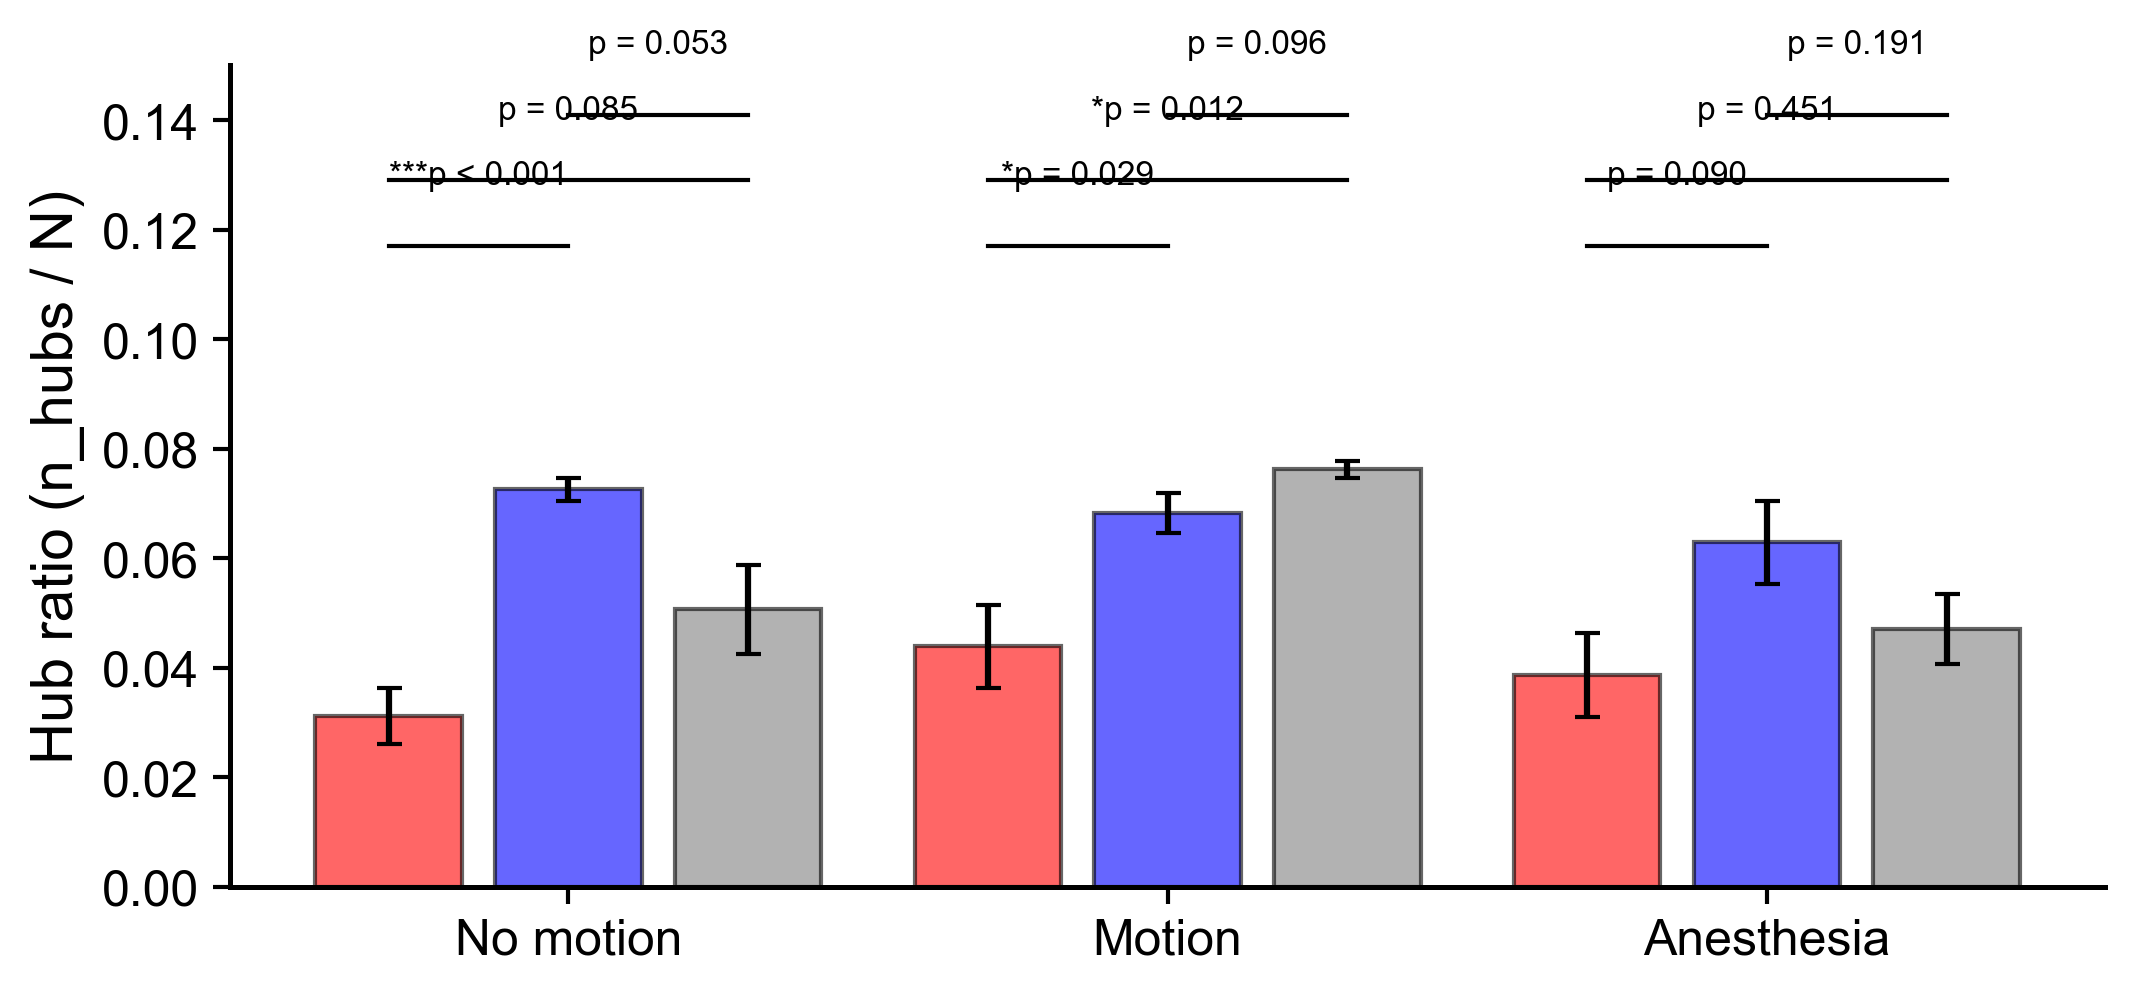

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind

# ---- settings ----
colors = {"positive": "red", "negative": "blue", "combined": "gray"}
states = ["No motion", "Motion", "Anesthesia"]
net_types = ["combined", "positive", "negative"]

bar_width = 0.22
inner_gap = 0.05
group_gap = 0.9

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if not np.isfinite(p):
        text = "p = n/a"
    elif p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + (h if h > 0 else 0) * 1.1 + 0.01,
            text, ha="center", va="bottom", fontsize=8)

def welch_p(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return ttest_ind(a, b, equal_var=False).pvalue

# ---- x positions ----
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")

# global range for sig lines
global_max = np.nanmax(df_hub_summary["hub_fraction"].values)
if not np.isfinite(global_max) or global_max <= 0:
    global_max = 0.1

# choose a y-limit a bit above max
y_top = max(0.15, global_max * 1.6)
ax.set_ylim(0, y_top)

# base y levels for the 3 pairwise lines within each state
y1 = y_top * 0.78
y2 = y_top * 0.86
y3 = y_top * 0.94
h = 0  # your style: no vertical height, just a straight line

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_summary[(df_hub_summary["state"] == s) &
                             (df_hub_summary["net_type"] == nt)]
        vals = sub["hub_fraction"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y1, h=h, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y2, h=h, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y3, h=h, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(states)
ax.set_ylabel("Hub ratio (n_hubs / N)")

# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
# Uncomment if you want legend
# ax.legend(handles=legend_handles, frameon=False,
#           loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
plt.show()

#### Hub features: profile

In [22]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

def compute_dff(plane0_path, neuropil_coeff=0.7, zscore=False, f0_percentile=20):
    F = np.load(Path(plane0_path) / "F.npy", allow_pickle=True)
    Fneu = np.load(Path(plane0_path) / "Fneu.npy", allow_pickle=True)
    iscell = np.load(Path(plane0_path) / "iscell.npy", allow_pickle=True)

    mask = (iscell[:, 0] == 1)
    Fcorr = (F - neuropil_coeff * Fneu)[mask, :]
    F0 = np.percentile(Fcorr, f0_percentile, axis=1, keepdims=True)
    dff = (Fcorr - F0) / (F0 + 1e-12)

    if zscore:
        mu = dff.mean(axis=1, keepdims=True)
        sd = dff.std(axis=1, keepdims=True) + 1e-12
        dff = (dff - mu) / sd

    return dff, mask  # dff: (n_cells x T)

# df_hubs_all columns: fov, suffix, state, net_type, node
# datasets entries have: fov, suffix, state, plane0
net_types = ["combined", "positive", "negative"]

hub_mean_traces = []   # list of dicts {fov,suffix,state,net_type,mean_trace(np.array)}
hub_trace_rows = []    # tidy long format per timepoint (optional but great for stats/plotting)
hub_meta_rows = []     # summary per sample (mean amplitude etc.)

for d in datasets:
    plane0 = d["plane0"]
    fov = d["fov"]
    suffix = int(d["suffix"])
    state = str(d["state"]).replace("_", " ")

    # load dff for this sample
    dff, mask = compute_dff(plane0, neuropil_coeff=0.7, zscore=False)

    n_cells, T = dff.shape

    for net_type in net_types:
        hubs = df_hubs_all[
            (df_hubs_all["fov"] == fov) &
            (df_hubs_all["suffix"] == suffix) &
            (df_hubs_all["net_type"] == net_type)
        ]["node"].to_numpy(dtype=int)

        # If no hubs (possible), skip gracefully
        if hubs.size == 0:
            continue

        # safety: keep only valid indices
        hubs = hubs[(hubs >= 0) & (hubs < n_cells)]
        if hubs.size == 0:
            continue

        dff_hubs = dff[hubs, :]               # (n_hubs x T)
        mean_trace = np.nanmean(dff_hubs, 0)  # (T,)

        hub_mean_traces.append({
            "fov": fov,
            "suffix": suffix,
            "state": state,
            "net_type": net_type,
            "n_cells": n_cells,
            "n_hubs": int(hubs.size),
            "T": int(T),
            "mean_trace": mean_trace,
        })

        # Optional: save long-format time series (makes plotting easy)
        hub_trace_rows.append(pd.DataFrame({
            "fov": fov,
            "suffix": suffix,
            "state": state,
            "net_type": net_type,
            "t": np.arange(T, dtype=int),
            "hub_mean_dff": mean_trace
        }))

        # Optional: quick scalar summaries per sample (useful for stats)
        hub_meta_rows.append({
            "fov": fov,
            "suffix": suffix,
            "state": state,
            "net_type": net_type,
            "n_hubs": int(hubs.size),
            "hub_mean_dff_mean": float(np.mean(mean_trace)),
            "hub_mean_dff_std": float(np.std(mean_trace)),
            "hub_mean_dff_auc": float(np.trapz(mean_trace)),  # if sampling interval uniform
            "hub_mean_dff_peak": float(np.max(mean_trace)),
        })

df_hub_trace = pd.concat(hub_trace_rows, ignore_index=True) if hub_trace_rows else pd.DataFrame()
df_hub_profile_summary = pd.DataFrame(hub_meta_rows)

print(df_hub_profile_summary.head())
print("Trace table rows:", len(df_hub_trace))

  fov  suffix      state  net_type  n_hubs  hub_mean_dff_mean  \
0  F1       0  No motion  combined      25           0.530970   
1  F1       0  No motion  positive      20           0.420765   
2  F1       0  No motion  negative      30           0.661476   
3  F1       1     Motion  combined      42           1.617448   
4  F1       1     Motion  positive      28           1.260767   

   hub_mean_dff_std  hub_mean_dff_auc  hub_mean_dff_peak  
0          0.486878       1061.026489           2.089401  
1          0.470002        840.679260           2.037690  
2          0.420785       1321.866943           1.558394  
3          0.737370       3231.488037           4.210292  
4          0.988755       2518.204590           5.690835  
Trace table rows: 52785


C:\Users\gp00062\AppData\Local\Temp\ipykernel_25180\473598899.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "hub_mean_dff_auc": float(np.trapz(mean_trace)),  # if sampling interval uniform


In [69]:
df_hub_profile_summary = pd.read_excel('hub_profile.xlsx')

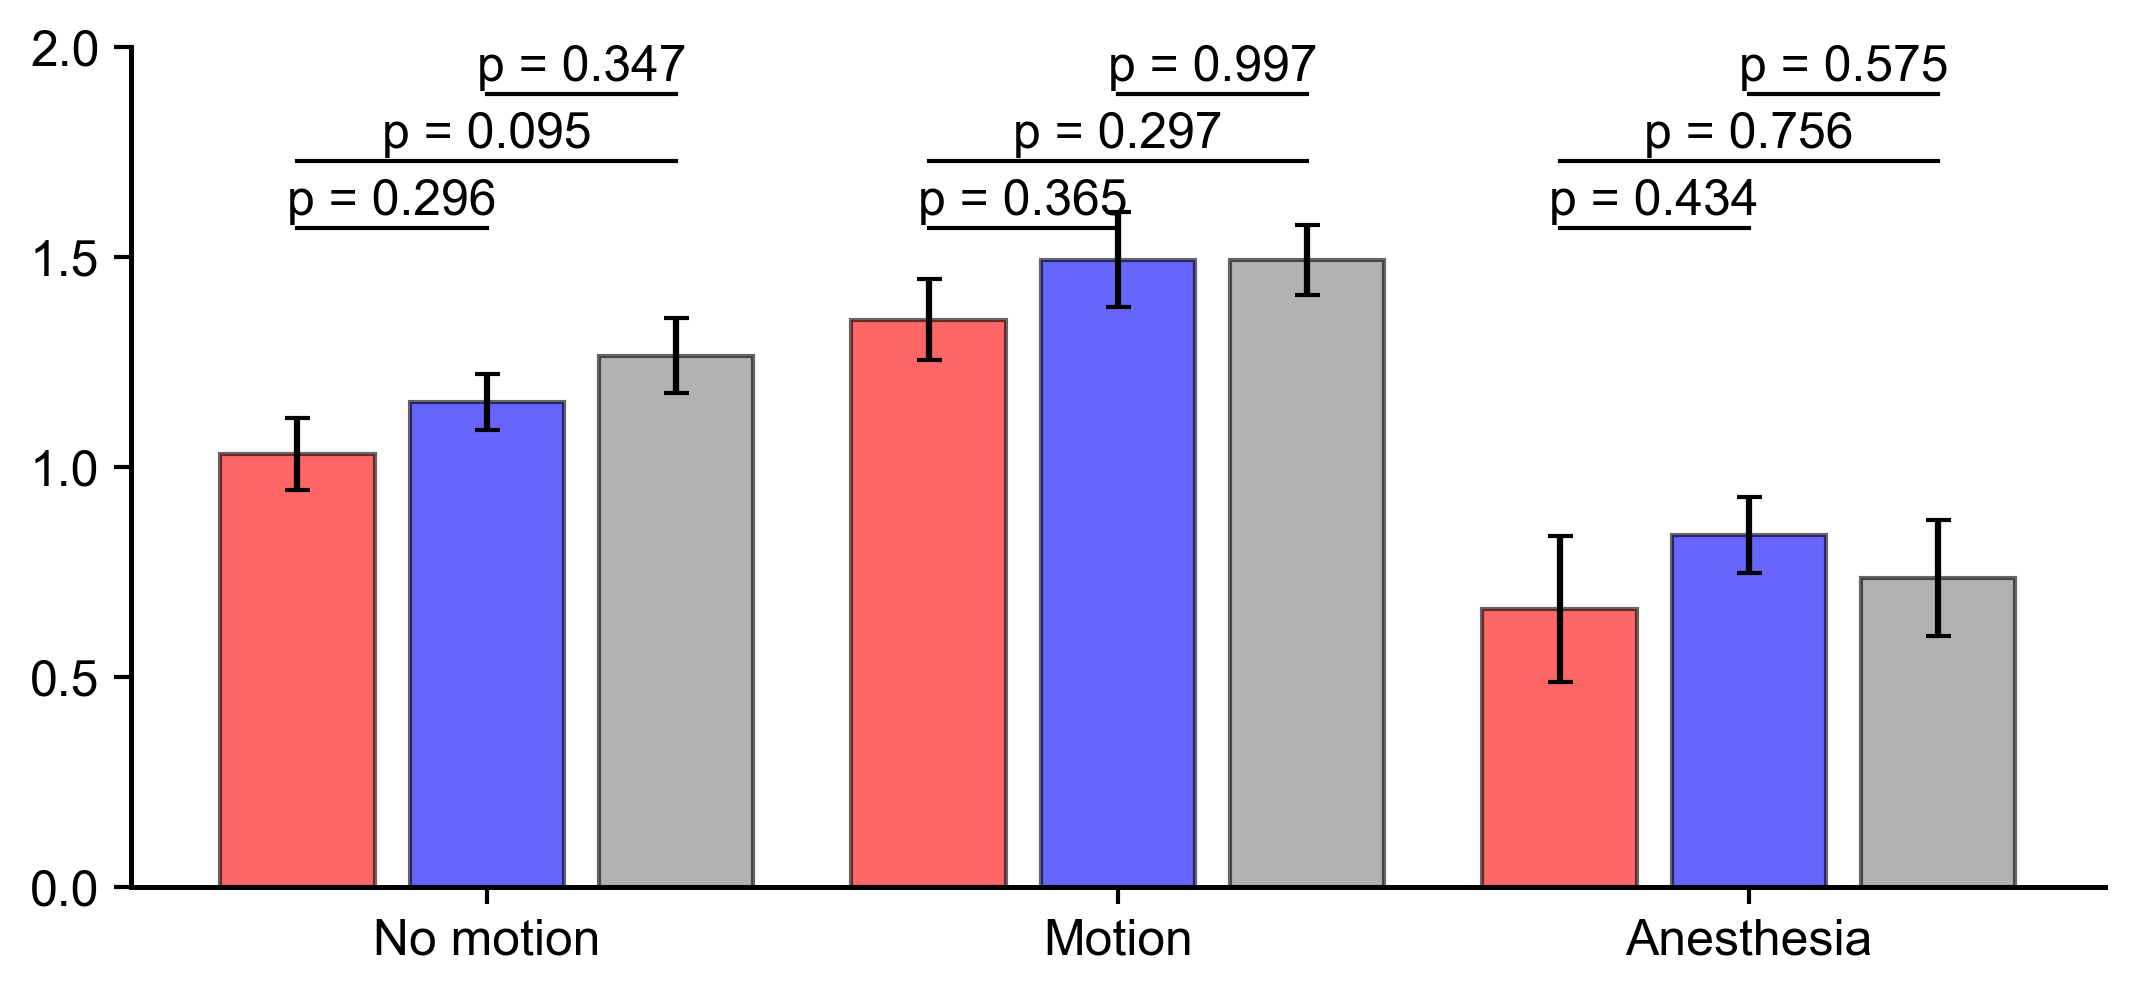

In [135]:
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
# global range for sig lines

def paper_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=4, width=1)

def mean_sem(vals):
    vals = np.array(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan, np.nan
    sem = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0
    return vals.mean(), sem

def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if not np.isfinite(p):
        text = "p = n/a"
    elif p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + (h if h > 0 else 0) * 1.1 + 0.01,
            text, ha="center", va="bottom")
global_max = np.nanmax(df_hub_profile_summary["hub_mean_dff_mean"].values)
if not np.isfinite(global_max) or global_max <= 0:
    global_max = 0.1

# choose a y-limit a bit above max
#y_top = max(0.15, global_max * 1.6)
ax.set_ylim(0, 2)
y_base = 1.6
ax.set_yticks([0, 0.5, 1.0, 1.5, 2.0])

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_profile_summary[(df_hub_profile_summary["state"] == s) &
                             (df_hub_profile_summary["net_type"] == nt)]
        vals = sub["hub_mean_dff_mean"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base*0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base*1.18, h=0, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(states)

# ax.set_ylabel(r"Mean $\Delta$F/F profile")
# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
# Uncomment if you want legend
# ax.legend(handles=legend_handles, frameon=False,
#           loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
fig.savefig(fig_path/'profile_all.svg')
plt.show()


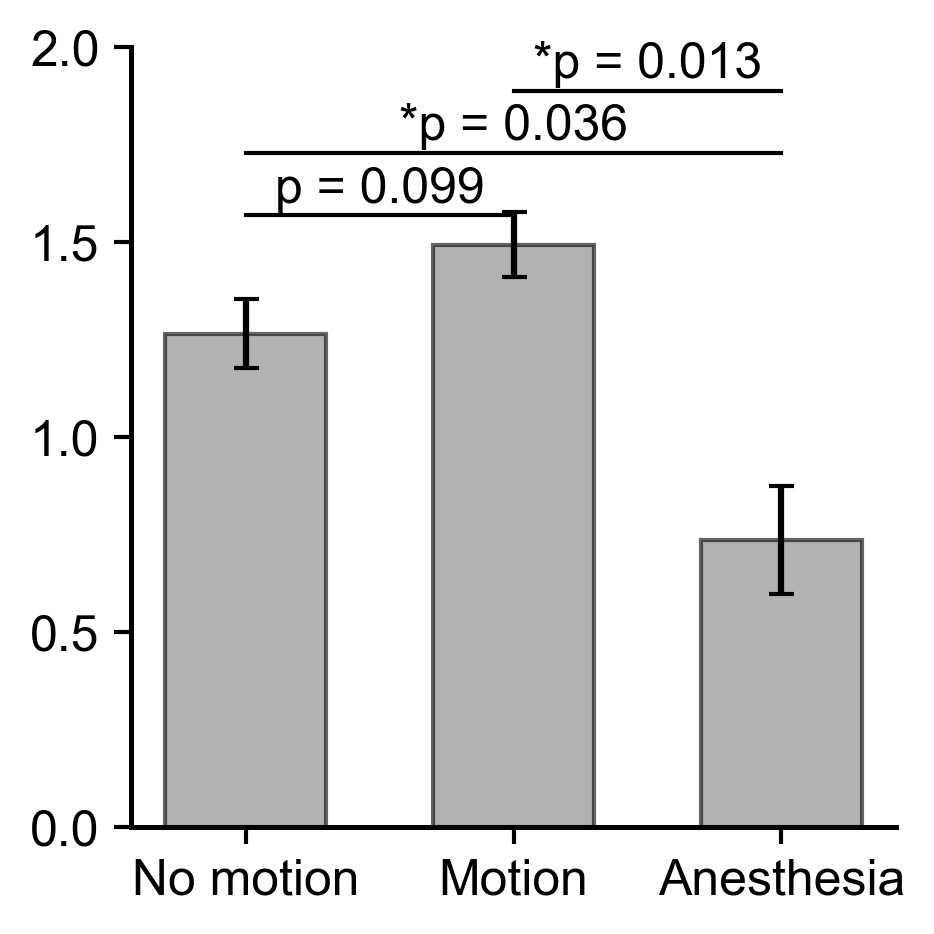

In [139]:
def single_nettype_barplot(df, metric_col, net_type_to_plot, ylabel, ylim,yticks,figname=None,fig_path=fig_path):
    df_filtered = df[df["net_type"] == net_type_to_plot].copy()

    fig, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
    x_positions = np.arange(len(states))

    vals_by_state = {}
    global_max = np.nanmax(df_filtered[metric_col].values)
    
    ax.set_ylim(0, ylim[1])
    ax.set_yticks(yticks)
    
    y_base = 0.8 * ylim[1]

    for i, st in enumerate(states):
        vals = df_filtered[df_filtered["state"] == st][metric_col].dropna().values
        vals_by_state[st] = vals
        m, se = mean_sem(vals)

        ax.bar(
            x_positions[i], m, width=0.6,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[net_type_to_plot], alpha=0.6
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(states)
    ax.set_ylabel(ylabel if net_type_to_plot == 'positive' else None)

    # across-state pairwise tests (within this net_type)
    y1 = y_base * 0.98
    y2 = y_base * 1.08
    y3 = y_base * 1.18

    p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
    p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
    p_m_a  = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])

    add_sig_line(ax, x_positions[0], x_positions[1], y=y1, h=0, p=p_nm_m)
    add_sig_line(ax, x_positions[0], x_positions[2], y=y2, h=0, p=p_nm_a)
    add_sig_line(ax, x_positions[1], x_positions[2], y=y3, h=0, p=p_m_a)

    paper_axes(ax)
    fig_name = f"{figname}.svg"
    fig.savefig(fig_path/fig_name)
    plt.show()

# Example: positive network only, peak ΔF/F
single_nettype_barplot(
    df=df_hub_profile_summary,
    metric_col="hub_mean_dff_mean",
    net_type_to_plot="combined",
    ylabel=r"Mean $\Delta$F/F profile",
    ylim = (0,2),
    yticks = [0, 0.5, 1.0, 1.5, 2.0],
    figname = 'profile_comb',
    fig_path = fig_path
)

In [221]:
df_hub_profile_summary[(df_hub_profile_summary['net_type'] == 'positive') & (df_hub_profile_summary['state'] == 'motion')]['hub_mean_dff_mean'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: hub_mean_dff_mean, dtype: float64

#### Features: degree

In [48]:
import numpy as np
import pandas as pd

net_types = ["combined", "positive", "negative"]

hub_degree_rows = []
hub_degree_summary_rows = []

for d in datasets:
    fov = d["fov"]
    suffix = int(d["suffix"])
    state = str(d["state"]).replace("_", " ")
    W_signed = d.get("adj_raw", None)
    if W_signed is None:
        continue

    variants = build_network_variants(W_signed)  # returns dict of matrices

    for net_type in net_types:
        W = variants[net_type]
        n = W.shape[0]

        hubs = df_hubs_all[
            (df_hubs_all["fov"] == fov) &
            (df_hubs_all["suffix"] == suffix) &
            (df_hubs_all["net_type"] == net_type)
        ]["node"].to_numpy(dtype=int)

        if hubs.size == 0:
            continue

        hubs = hubs[(hubs >= 0) & (hubs < n)]
        if hubs.size == 0:
            continue

        # degree = count of nonzero edges in that row (excluding diagonal)
        degrees = []
        for h in hubs:
            row = W[h, :]
            deg = int(np.sum(row > 0) - (row[h] > 0))
            degrees.append(deg)

        degrees = np.asarray(degrees, dtype=int)

        # per-hub rows
        for h, deg in zip(hubs, degrees):
            hub_degree_rows.append({
                "fov": fov,
                "suffix": suffix,
                "state": state,
                "net_type": net_type,
                "node": int(h),
                "hub_degree": int(deg),
            })

        # per-sample summary (for barplots)
        hub_degree_summary_rows.append({
            "fov": fov,
            "suffix": suffix,
            "state": state,
            "net_type": net_type,
            "n_hubs": int(len(degrees)),
            "mean_hub_degree": float(np.mean(degrees)),
            "median_hub_degree": float(np.median(degrees)),
        })

df_hub_degree_nodes = pd.DataFrame(hub_degree_rows)
df_hub_degree_summary = pd.DataFrame(hub_degree_summary_rows)

print(df_hub_degree_summary.head())

  fov  suffix      state  net_type  n_hubs  mean_hub_degree  median_hub_degree
0  F1       0  No motion  combined      25       152.040000              144.0
1  F1       0  No motion  positive      20       136.450000              136.0
2  F1       0  No motion  negative      30        32.600000               31.5
3  F1       1     Motion  combined      42       157.000000              150.5
4  F1       1     Motion  positive      28       118.928571              118.5


In [140]:
df_hub_degree_summary = pd.read_excel('hub_degree.xlsx')

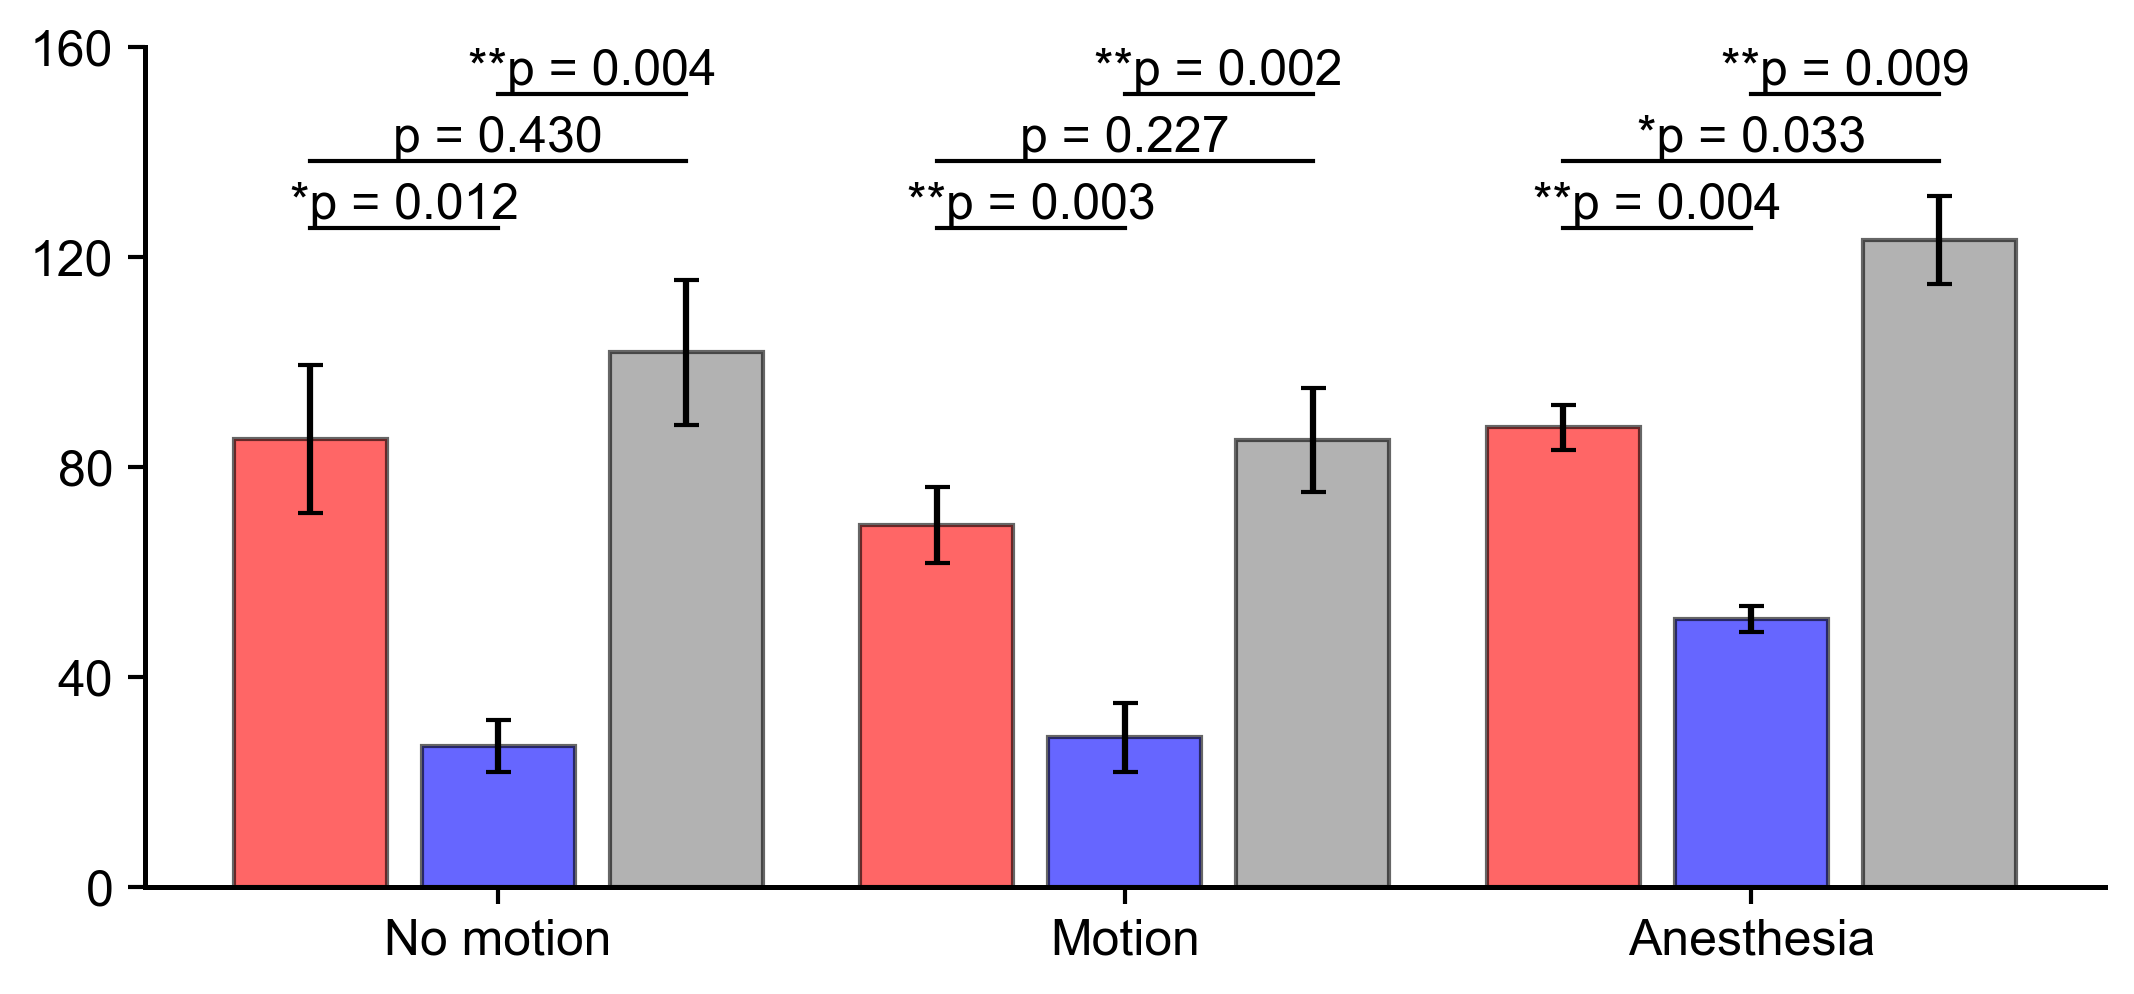

In [141]:
indices = np.arange(len(states)) * group_gap
offsets = {
    "positive": -(bar_width + inner_gap),
    "negative": 0.0,
    "combined": +(bar_width + inner_gap),
}

# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
# global range for sig lines

# choose a y-limit a bit above max
#y_top = max(0.15, global_max * 1.6)
ax.set_ylim(0, 160)
y_base = 128
ax.set_yticks([0, 40, 80, 120, 160])

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_degree_summary[(df_hub_profile_summary["state"] == s) &
                             (df_hub_degree_summary["net_type"] == nt)]
        vals = sub["mean_hub_degree"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base*0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base*1.18, h=0, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(states)

# ax.set_ylabel(r"Mean $\Delta$F/F profile")

# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
# Uncomment if you want legend
# ax.legend(handles=legend_handles, frameon=False,
#           loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
plt.show()
fig.savefig(fig_path/'degree_all.svg')

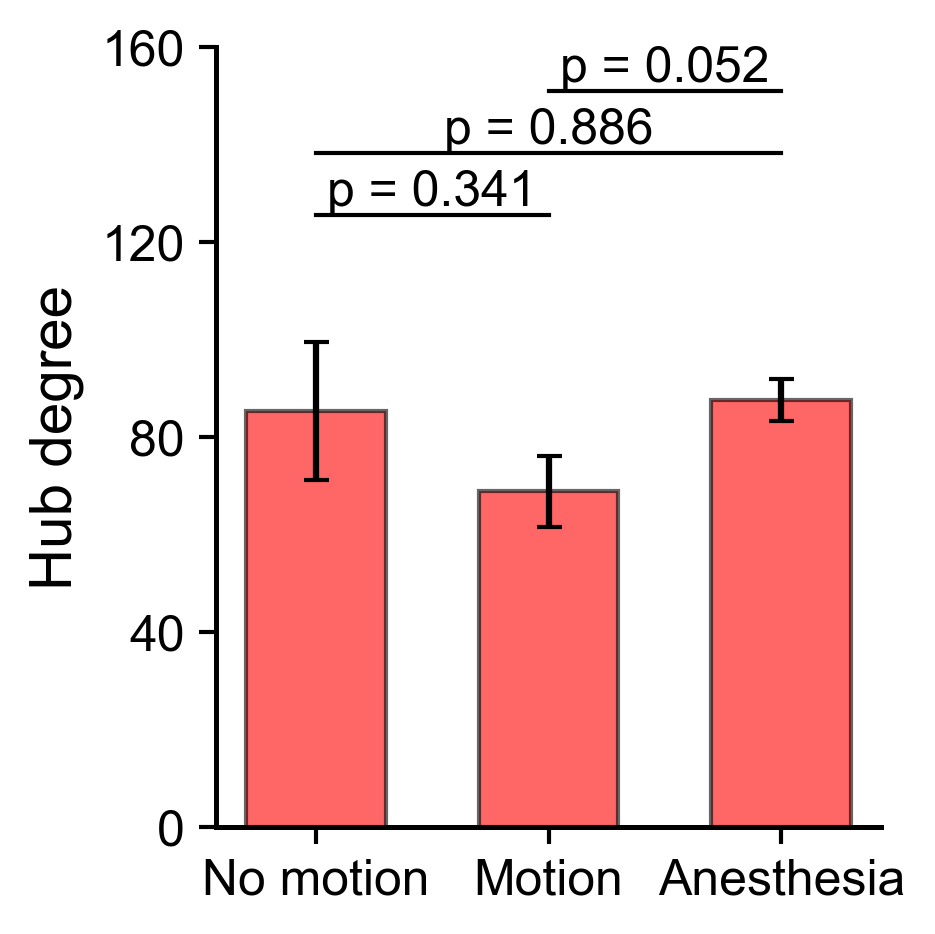

In [222]:
single_nettype_barplot(
    df=df_hub_degree_summary,
    metric_col="mean_hub_degree",
    net_type_to_plot="positive",
    ylabel=r"Hub degree",
    ylim = (0,160),
    yticks = [0, 40, 80, 120, 160],
    figname = 'degree_pos'
)

In [228]:
df_hub_degree_summary[(df_hub_degree_summary['net_type'] == 'combined') & (df_hub_degree_summary['state'] == 'Anesthesia')]['mean_hub_degree'].describe()

count      3.000000
mean     123.251667
std       14.515303
min      108.075000
25%      116.377500
50%      124.680000
75%      130.840000
max      137.000000
Name: mean_hub_degree, dtype: float64

##### df_hub_degree_summary.head()

#### Feature: edge strength

In [62]:
import numpy as np
import pandas as pd

net_types = ["combined", "positive", "negative"]

edge_strength_rows = []
edge_strength_summary_rows = []

for d in datasets:
    fov = d["fov"]
    suffix = int(d["suffix"])
    state = str(d["state"]).replace("_", " ")
    W_signed = d.get("adj_raw", None)
    if W_signed is None:
        continue

    variants = build_network_variants(W_signed)

    for net_type in net_types:
        W = variants[net_type]
        n = W.shape[0]

        hubs = df_hubs_all[
            (df_hubs_all["fov"] == fov) &
            (df_hubs_all["suffix"] == suffix) &
            (df_hubs_all["net_type"] == net_type)
        ]["node"].to_numpy(dtype=int)

        if hubs.size == 0:
            continue
        hubs = hubs[(hubs >= 0) & (hubs < n)]
        if hubs.size == 0:
            continue

        per_hub_mean_w = []
        for h in hubs:
            row = W[h, :].copy()

            mask = (row > 0)
            mask[h] = False  # exclude self

            weights = row[mask]
            mean_w = float(np.mean(weights)) if weights.size > 0 else np.nan
            per_hub_mean_w.append(mean_w)

            edge_strength_rows.append({
                "fov": fov,
                "suffix": suffix,
                "state": state,
                "net_type": net_type,
                "node": int(h),
                "hub_mean_edge_strength": mean_w,
                "hub_degree": int(weights.size),  # convenient to keep
            })

        per_hub_mean_w = np.asarray(per_hub_mean_w, dtype=float)

        edge_strength_summary_rows.append({
            "fov": fov,
            "suffix": suffix,
            "state": state,
            "net_type": net_type,
            "n_hubs": int(len(per_hub_mean_w)),
            "mean_hub_edge_strength": float(np.nanmean(per_hub_mean_w)),
            "median_hub_edge_strength": float(np.nanmedian(per_hub_mean_w)),
            "frac_nan_hubs": float(np.mean(~np.isfinite(per_hub_mean_w))),
        })

df_hub_strength_nodes = pd.DataFrame(edge_strength_rows)
df_hub_strength_summary = pd.DataFrame(edge_strength_summary_rows)

print(df_hub_strength_summary.head())

  fov  suffix      state  net_type  n_hubs  mean_hub_edge_strength  \
0  F1       0  No motion  combined      25                     1.0   
1  F1       0  No motion  positive      20                     1.0   
2  F1       0  No motion  negative      30                     1.0   
3  F1       1     Motion  combined      42                     1.0   
4  F1       1     Motion  positive      28                     1.0   

   median_hub_edge_strength  frac_nan_hubs  
0                       1.0            0.0  
1                       1.0            0.0  
2                       1.0            0.0  
3                       1.0            0.0  
4                       1.0            0.0  


In [145]:
df_hub_strength_summary = pd.read_excel('hub_strength.xlsx')

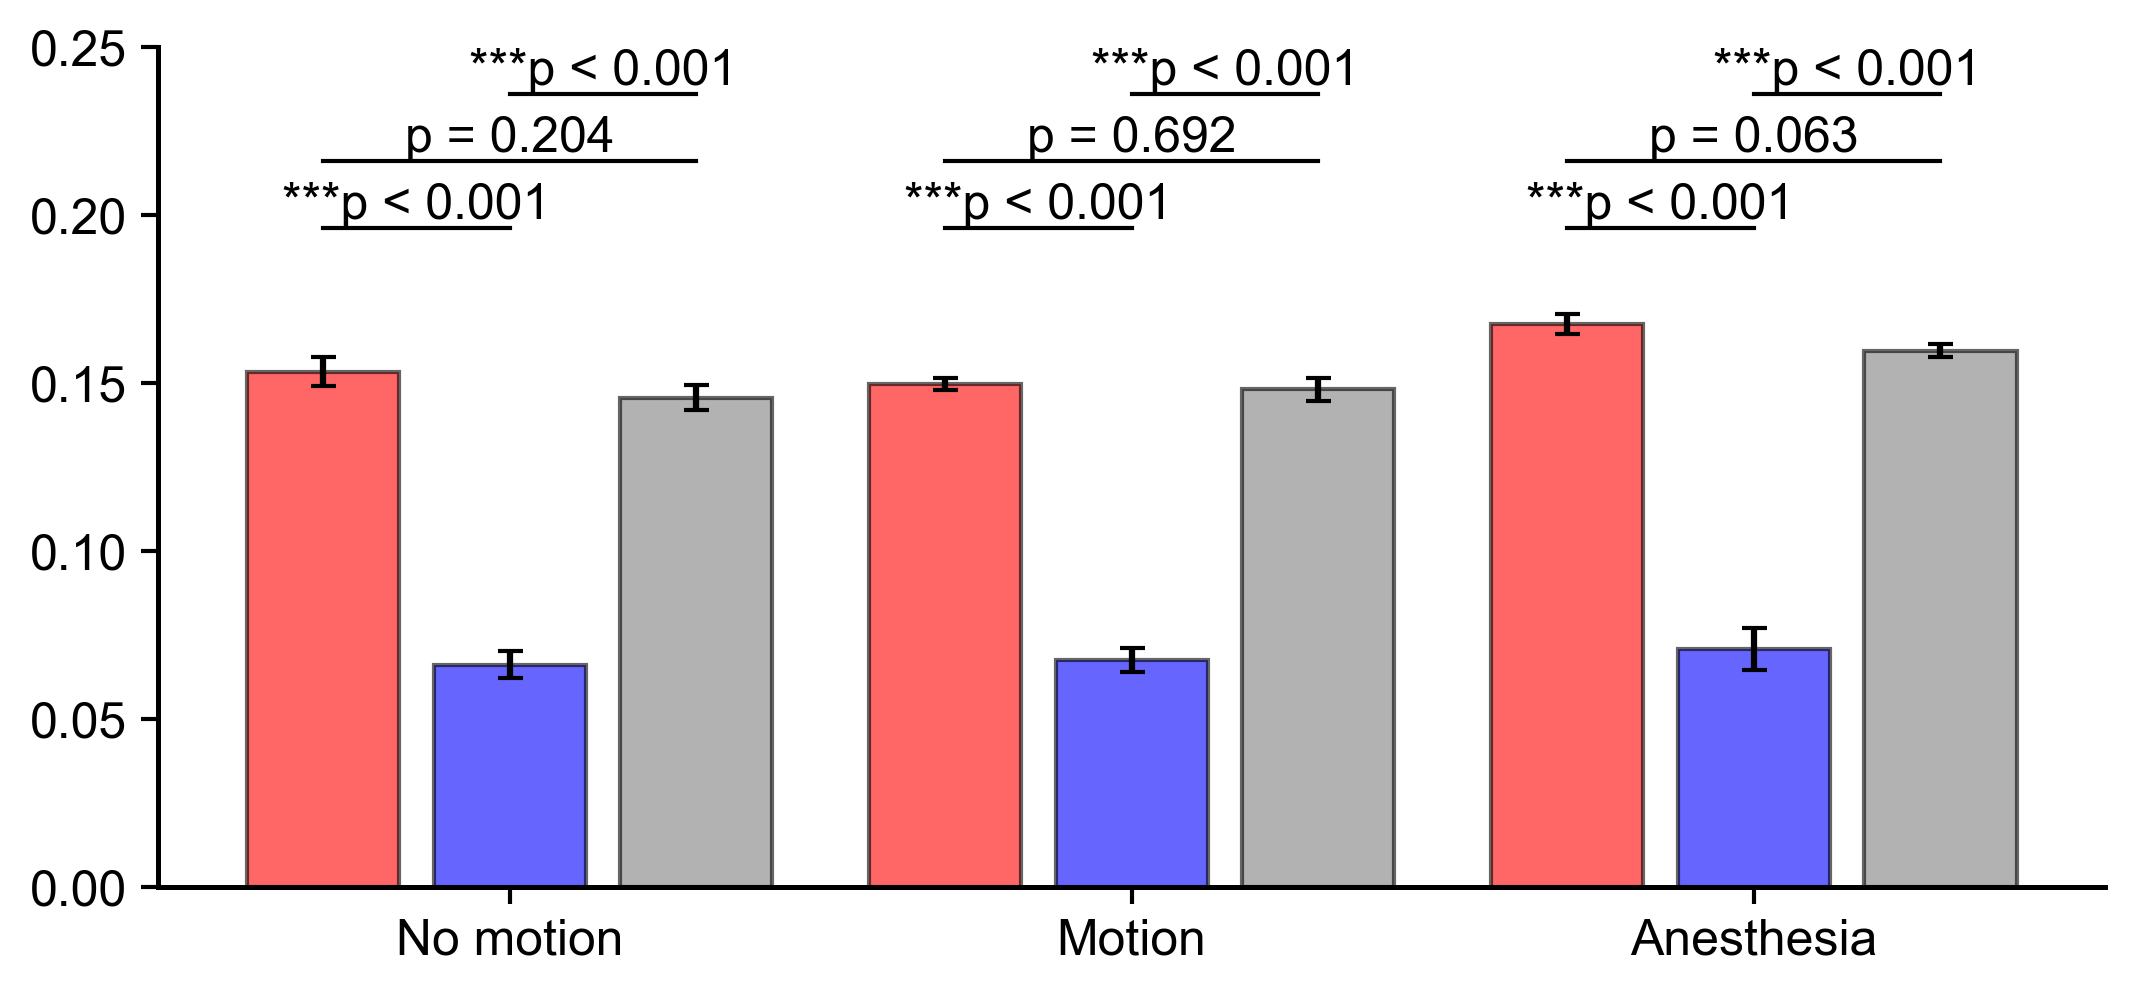

In [230]:
indices = np.arange(len(states)) * group_gap
# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
# global range for sig lines

# choose a y-limit a bit above max
states = ['No motion', 'Anesthesia', 'Motion']
ax.set_ylim(0, 0.25)
y_base = 0.2
ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20, 0.25])
def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if not np.isfinite(p):
        text = "p = n/a"
    elif p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + (h if h > 0 else 0) * 1.1,
            text, ha="center", va="bottom")

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_strength_summary[(df_hub_strength_summary["state"] == s) &
                             (df_hub_strength_summary["net_type"] == nt)]
        vals = sub["mean_hub_edge_strength"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base*0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base*1.18, h=0, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])

# ax.set_ylabel(r"Mean $\Delta$F/F profile")

# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]

paper_axes(ax)
plt.show()
fig.savefig(fig_path/'strength_all.svg')

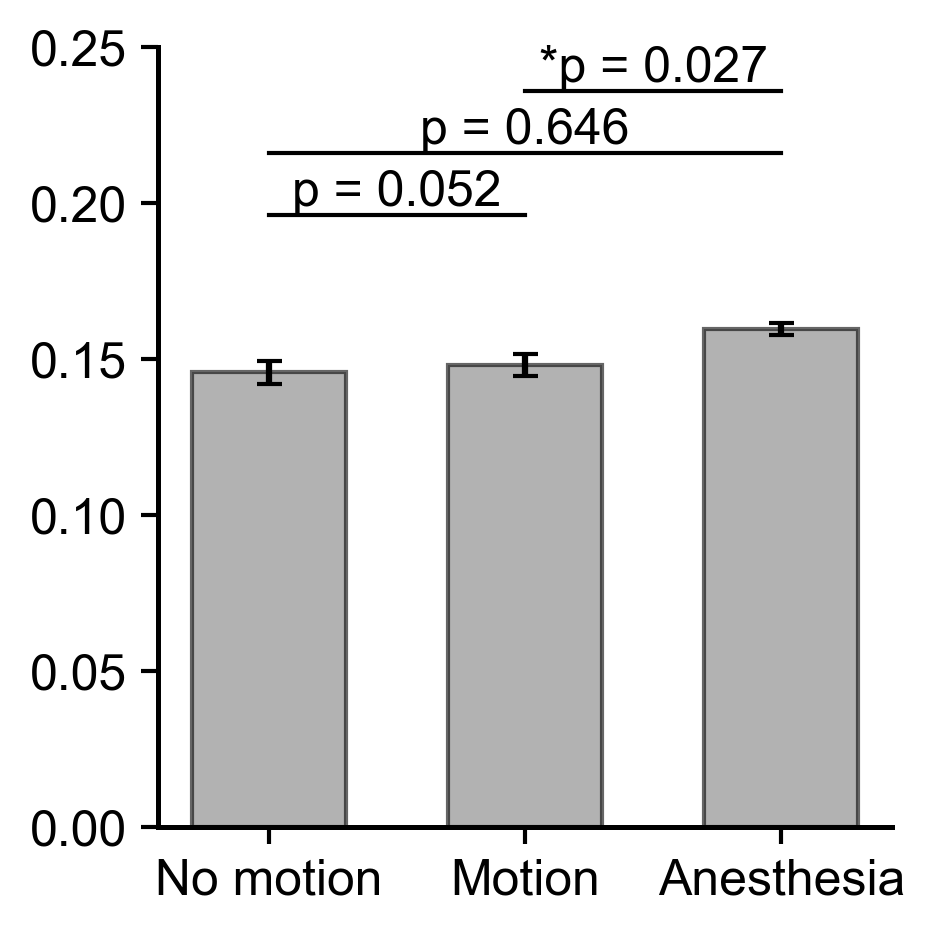

In [238]:

single_nettype_barplot(
    df=df_hub_strength_summary,
    metric_col="mean_hub_edge_strength",
    net_type_to_plot="combined",
    ylabel=r"Hub strengths",
    ylim = (0,0.25),
    yticks = [0, 0.05, 0.10, 0.15, 0.20, 0.25],
    figname = 'strength_comb'
)

In [243]:
df_hub_strength_summary[(df_hub_strength_summary['net_type'] == 'negative') & (df_hub_strength_summary['state'] == 'Motion')]['mean_hub_edge_strength'].describe()

count    5.000000
mean     0.070880
std      0.013952
min      0.056000
25%      0.056000
50%      0.078200
75%      0.078200
max      0.086000
Name: mean_hub_edge_strength, dtype: float64

#### Feature: distance

In [104]:

pair_rows = []      # one row per hub-hub pair (optional, good for violin later)
summary_rows = []   # one row per sample x net_type (for barplots)

for d in datasets:
    fov = d["fov"]
    suffix = int(d["suffix"])
    state = str(d["state"]).replace("_", " ")
    plane0 = Path(d["plane0"])

    # Load suite2p outputs
    stat = np.load(plane0 / "stat.npy", allow_pickle=True)
    iscell = np.load(plane0 / "iscell.npy", allow_pickle=True)

    mask = (iscell[:, 0] == 1)
    cell_idx = np.where(mask)[0]  # indices in stat for kept cells

    for net_type in net_types:
        hubs = df_hubs_all[
            (df_hubs_all["fov"] == fov) &
            (df_hubs_all["suffix"] == suffix) &
            (df_hubs_all["net_type"] == net_type)
        ]["node"].to_numpy(dtype=int)

        if hubs.size == 0:
            continue

        # Map masked hub indices -> stat indices
        hubs = hubs[(hubs >= 0) & (hubs < len(cell_idx))]
        if hubs.size == 0:
            continue

        hub_stat_idx = cell_idx[hubs]

        # Extract [y,x] coordinates (Suite2p stat 'med')
        coords = np.array([stat[i]["med"] for i in hub_stat_idx], dtype=float)  # (n_hubs, 2)
        n_hubs = coords.shape[0]

        if n_hubs <= 1:
            summary_rows.append({
                "fov": fov, "suffix": suffix, "state": state, "net_type": net_type,
                "n_hubs": int(n_hubs),
                "mean_pairwise_hub_dist_px": np.nan,
                "median_pairwise_hub_dist_px": np.nan,
                "min_pairwise_hub_dist_px": np.nan,
                "max_pairwise_hub_dist_px": np.nan,
                "n_pairs": 0
            })
            continue

        # Pairwise distances
        diff = coords[:, None, :] - coords[None, :, :]
        dist_mat = np.sqrt(np.sum(diff**2, axis=-1))

        iu = np.triu_indices(n_hubs, k=1)
        pair_dists = dist_mat[iu]  # length = n_pairs

        # Save pairwise rows (optional)
        # store which pair for reproducibility
        for (i, j), dist in zip(zip(iu[0], iu[1]), pair_dists):
            pair_rows.append({
                "fov": fov, "suffix": suffix, "state": state, "net_type": net_type,
                "hub_i": int(hubs[i]),
                "hub_j": int(hubs[j]),
                "pair_dist_px": float(dist),
            })

        # Summary row (for barplots)
        summary_rows.append({
            "fov": fov, "suffix": suffix, "state": state, "net_type": net_type,
            "n_hubs": int(n_hubs),
            "mean_pairwise_hub_dist_px": float(np.mean(pair_dists)),
            "median_pairwise_hub_dist_px": float(np.median(pair_dists)),
            "min_pairwise_hub_dist_px": float(np.min(pair_dists)),
            "max_pairwise_hub_dist_px": float(np.max(pair_dists)),
            "n_pairs": int(pair_dists.size)
        })

df_hub_spatial_pairs = pd.DataFrame(pair_rows)
df_hub_spatial_summary = pd.DataFrame(summary_rows)

print(df_hub_spatial_summary.head())

  fov  suffix      state  net_type  n_hubs  mean_pairwise_hub_dist_px  \
0  F1       0  No motion  combined      25                 270.982352   
1  F1       0  No motion  positive      20                 247.642263   
2  F1       0  No motion  negative      30                 268.040820   
3  F1       1     Motion  combined      42                 219.291945   
4  F1       1     Motion  positive      28                 257.647948   

   median_pairwise_hub_dist_px  min_pairwise_hub_dist_px  \
0                   269.288096                 17.029386   
1                   250.985384                 28.844410   
2                   252.982213                 17.029386   
3                   210.523158                  5.830952   
4                   245.724495                  9.486833   

   max_pairwise_hub_dist_px  n_pairs  
0                716.096362      300  
1                688.222348      190  
2                690.554849      435  
3                520.622704      861  
4    

In [152]:
df_hub_spatial_summary = pd.read_excel('hub_spatial.xlsx')

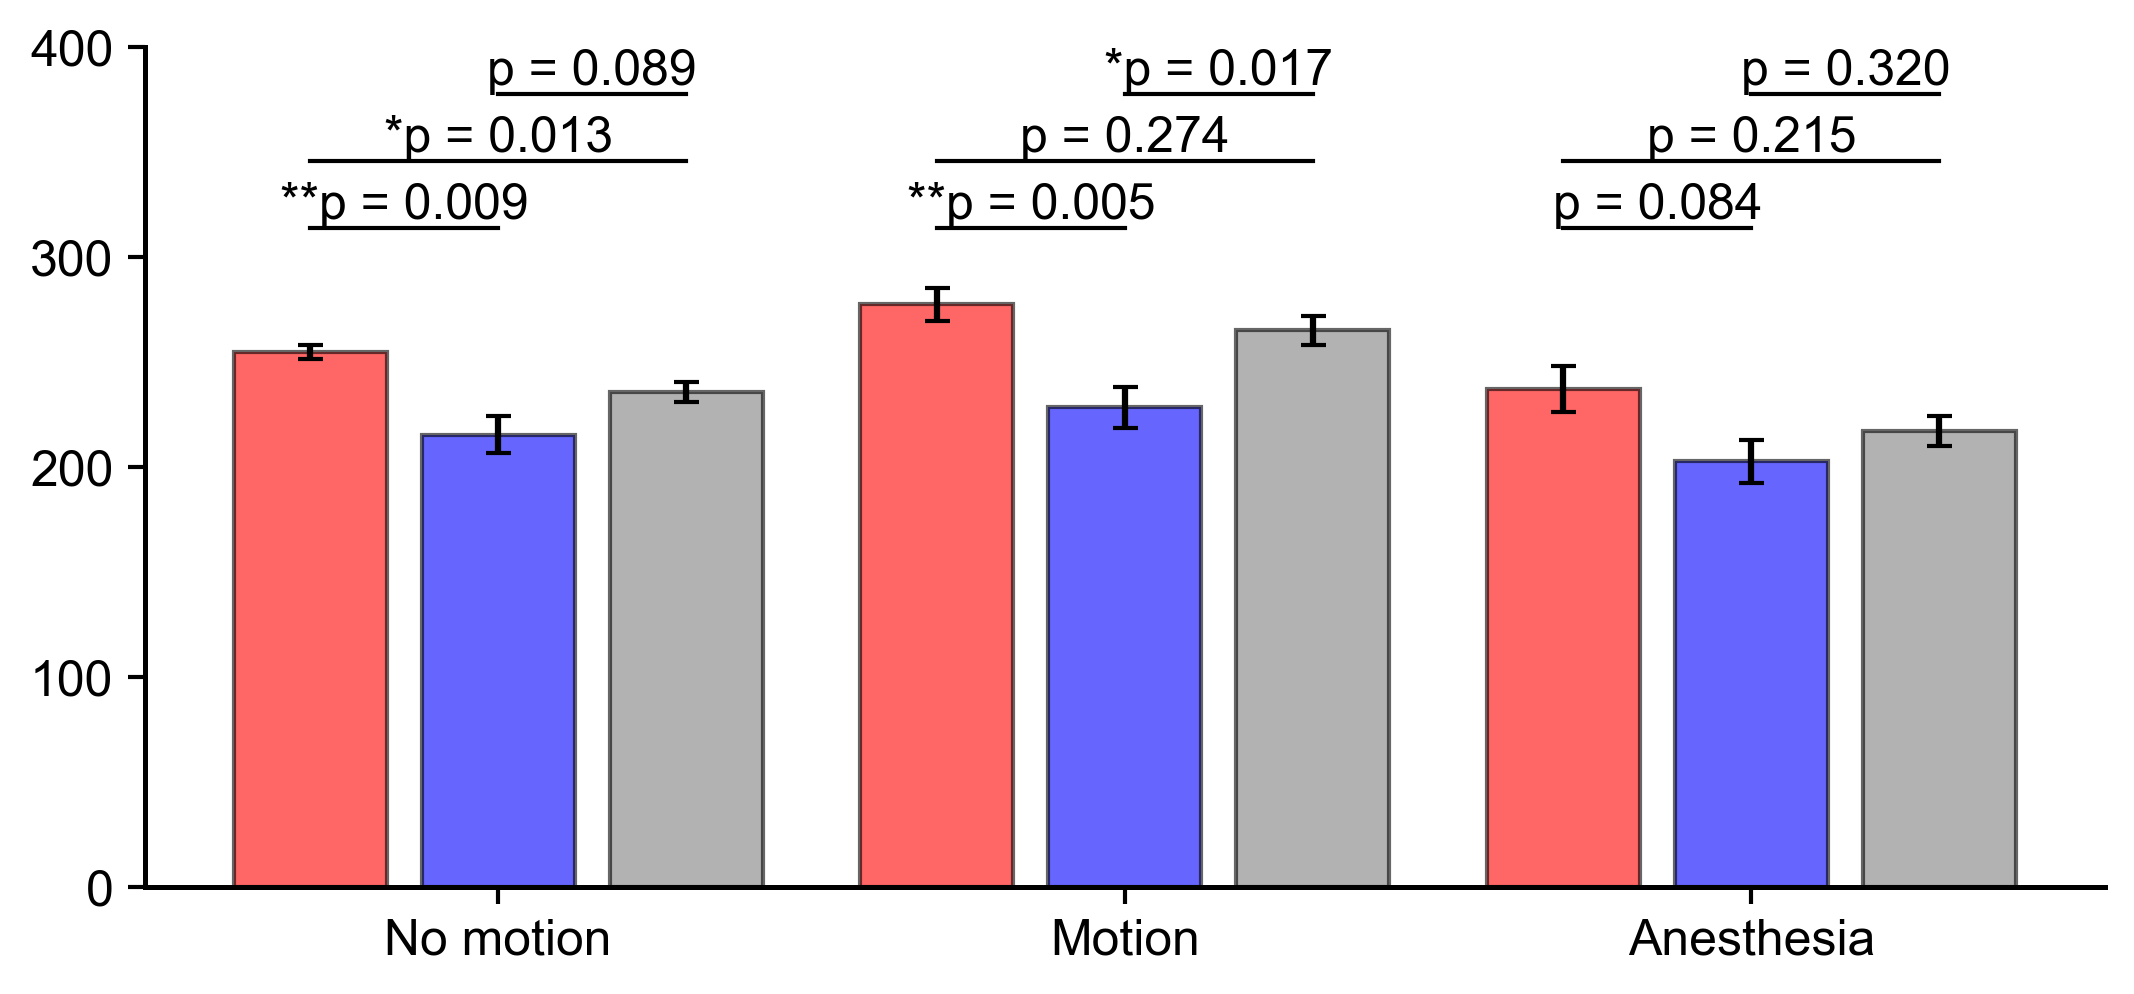

In [153]:
indices = np.arange(len(states)) * group_gap
# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})
# global range for sig lines

# choose a y-limit a bit above max

ax.set_ylim(0, 400)
y_base = 320
ax.set_yticks([0, 100, 200, 300, 400])

for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_spatial_summary[(df_hub_spatial_summary["state"] == s) &
                             (df_hub_spatial_summary["net_type"] == nt)]
        vals = sub["mean_dist_px"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y_base*0.98, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y_base*1.08, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y_base*1.18, h=0, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(states)

# ax.set_ylabel(r"Mean $\Delta$F/F profile")

# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]

paper_axes(ax)
plt.show()
fig.savefig(fig_path/'spatial_all.svg')

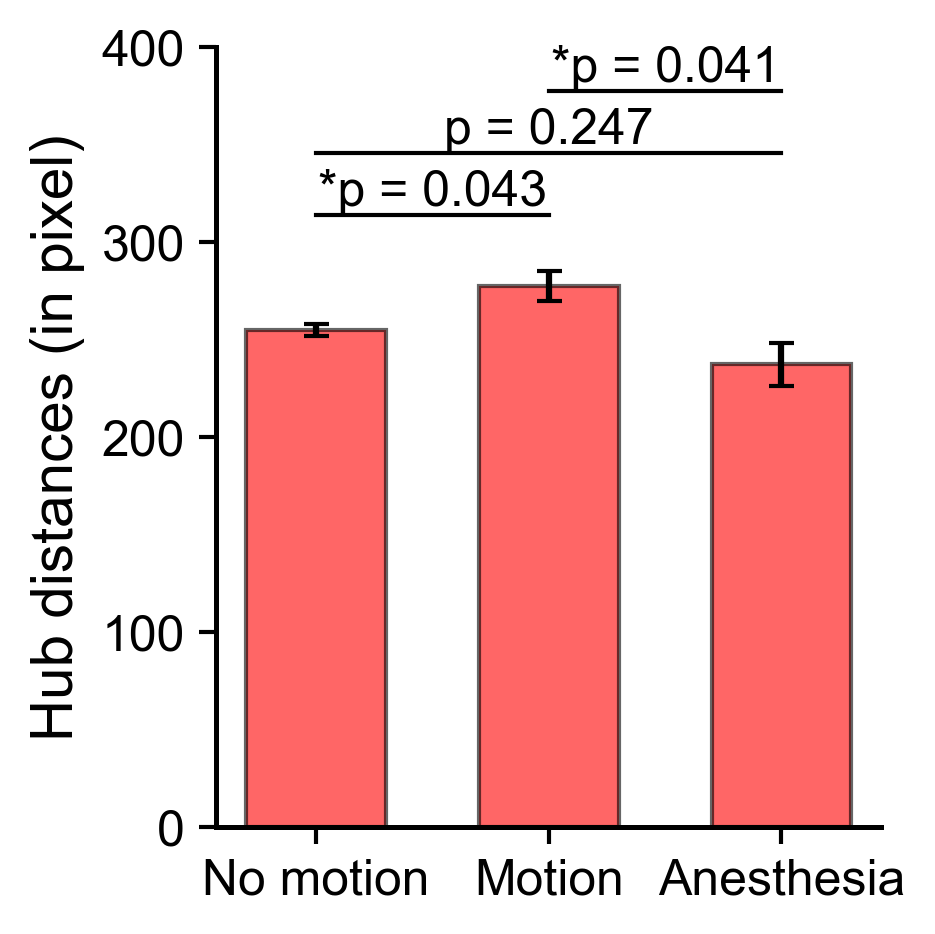

In [245]:
states = ['No motion', 'Motion', 'Anesthesia']
def single_nettype_barplot(df, metric_col, net_type_to_plot, ylabel, ylim,yticks,figname=None,fig_path=fig_path):
    df_filtered = df[df["net_type"] == net_type_to_plot].copy()

    fig, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
    x_positions = np.arange(len(states))

    vals_by_state = {}
    global_max = np.nanmax(df_filtered[metric_col].values)
    
    ax.set_ylim(0, ylim[1])
    ax.set_yticks(yticks)
    
    y_base = 0.8 * ylim[1]

    for i, st in enumerate(states):
        vals = df_filtered[df_filtered["state"] == st][metric_col].dropna().values
        vals_by_state[st] = vals
        m, se = mean_sem(vals)

        ax.bar(
            x_positions[i], m, width=0.6,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[net_type_to_plot], alpha=0.6
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(states)
    ax.set_ylabel(ylabel if net_type_to_plot == 'positive' else None)

    # across-state pairwise tests (within this net_type)
    y1 = y_base * 0.98
    y2 = y_base * 1.08
    y3 = y_base * 1.18

    p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
    p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
    p_m_a  = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])

    add_sig_line(ax, x_positions[0], x_positions[1], y=y1, h=0, p=p_nm_m)
    add_sig_line(ax, x_positions[0], x_positions[2], y=y2, h=0, p=p_nm_a)
    add_sig_line(ax, x_positions[1], x_positions[2], y=y3, h=0, p=p_m_a)

    paper_axes(ax)
    fig_name = f"{figname}.svg"
    fig.savefig(fig_path/fig_name)
    plt.show()

# Example: positive network only, peak ΔF/F

single_nettype_barplot(
    df=df_hub_spatial_summary,
    metric_col="mean_dist_px",
    net_type_to_plot="positive",
    ylabel=r"Hub distances (in pixel)",
    ylim = (0,400),
    yticks = [0,100,200, 300, 400],
    figname = 'spatial_pos'
)

#### Re-usable plot

#### Hub ratio and numbers

In [174]:
df_hub_summary = pd.read_excel('hub_numbers.xlsx')

In [176]:
df_hub_summary['hub_ratio'] = df_hub_summary['hub_number']/df_hub_summary['N']

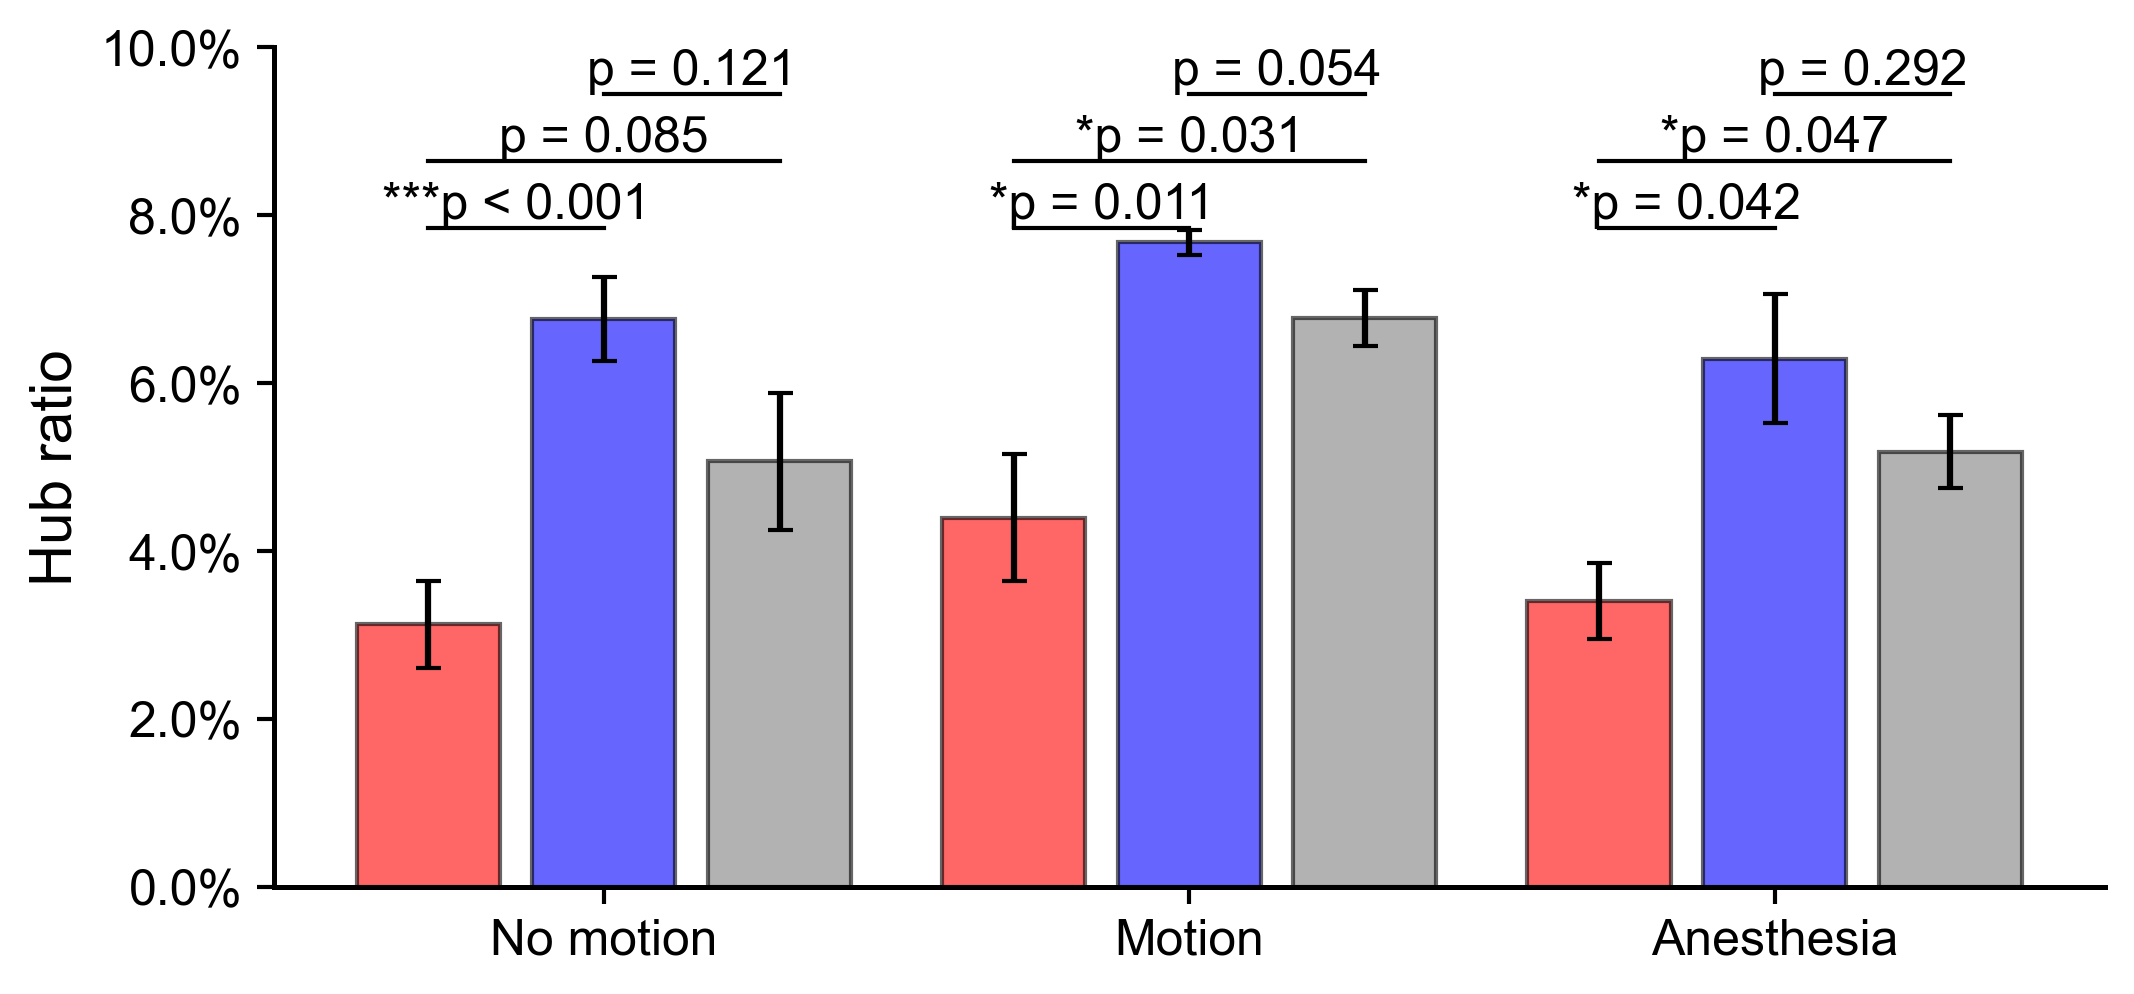

In [202]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import ttest_ind
import matplotlib.ticker as mtick
# ---- settings ----
colors = {"positive": "red", "negative": "blue", "combined": "gray"}
states = ["No motion", "Motion", "Anesthesia"]
net_types = ["combined", "positive", "negative"]

bar_width = 0.22
inner_gap = 0.05
group_gap = 0.9


def add_sig_line(ax, x1, x2, y, h, p):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c="black")
    if not np.isfinite(p):
        text = "p = n/a"
    elif p < 0.001:
        text = "***p < 0.001"
    elif p < 0.01:
        text = f"**p = {p:.3f}"
    elif p < 0.05:
        text = f"*p = {p:.3f}"
    else:
        text = f"p = {p:.3f}"
    ax.text((x1 + x2) / 2, y + (h if h > 0 else 0) * 1.1,
            text, ha="center", va="bottom")
# ---- plot ----
fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300, layout="constrained")

# global range for sig lines
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"], # Standard journal fonts
    "font.size": 12,                           # Base font size
    "axes.labelsize": 14,                      # Axis titles
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,                     # Thickness of the frame
    "lines.linewidth": 1.5,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "pdf.fonttype": 42,                        # Ensures text is editable in Illustrator/Affinity
    "ps.fonttype": 42
})

ax.set_ylim(0, 0.1)
y_base = 0.08
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
# base y levels for the 3 pairwise lines within each state
y1 = y_base * 0.98
y2 = y_base * 1.08
y3 = y_base * 1.18
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, s in enumerate(states):
    xs = {}
    vals_by_type = {}

    for nt in net_types:
        sub = df_hub_summary[(df_hub_summary["state"] == s) &
                             (df_hub_summary["net_type"] == nt)]
        vals = sub["hub_ratio"].dropna().values
        vals_by_type[nt] = vals

        m, se = mean_sem(vals)
        x_pos = indices[i] + offsets[nt]
        xs[nt] = x_pos

        ax.bar(
            x_pos, m, width=bar_width,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[nt], alpha=0.6
        )

    # ---- within-state pairwise Welch tests ----
    p_pos_neg = welch_p(vals_by_type["positive"], vals_by_type["negative"])
    p_pos_com = welch_p(vals_by_type["positive"], vals_by_type["combined"])
    p_neg_com = welch_p(vals_by_type["negative"], vals_by_type["combined"])

    add_sig_line(ax, xs["positive"], xs["negative"], y=y1, h=0, p=p_pos_neg)
    add_sig_line(ax, xs["positive"], xs["combined"], y=y2, h=0, p=p_pos_com)
    add_sig_line(ax, xs["negative"], xs["combined"], y=y3, h=0, p=p_neg_com)

# ---- labels ----
ax.set_xticks(indices)
ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
ax.set_ylabel("Hub ratio")


h = 0  # your style: no vertical height, just a straight line
# ---- legend ----
legend_handles = [
    Patch(facecolor=colors["positive"], edgecolor="black", label="Positive", alpha=0.6),
    Patch(facecolor=colors["negative"], edgecolor="black", label="Negative", alpha=0.6),
    Patch(facecolor=colors["combined"], edgecolor="black", label="Combined", alpha=0.6),
]
# Uncomment if you want legend
# ax.legend(handles=legend_handles, frameon=False,
#           loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3)

paper_axes(ax)
fig.savefig(fig_path/'hub_ratio_all.svg')
plt.show()

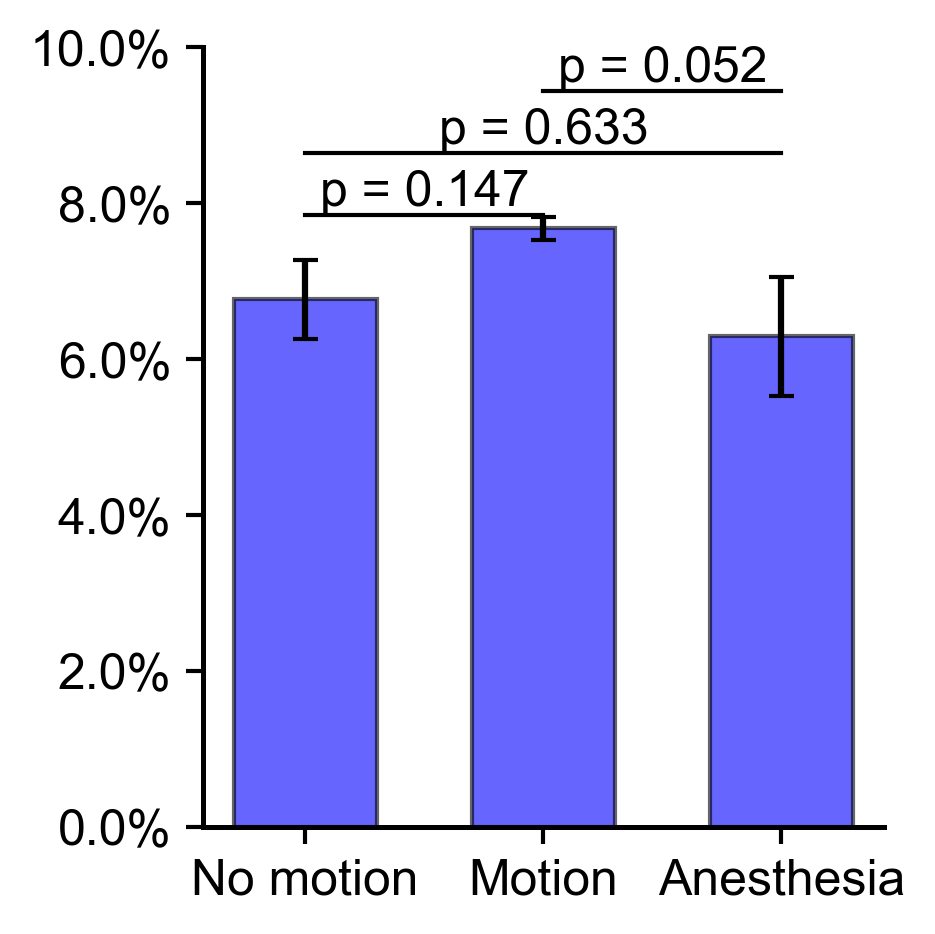

In [204]:
def single_nettype_barplot(df, metric_col, net_type_to_plot, ylabel, ylim,yticks,figname=None,fig_path=fig_path, percent=False):
    import matplotlib.ticker as mtick
    df_filtered = df[df["net_type"] == net_type_to_plot].copy()
    fig, ax = plt.subplots(figsize=(3, 3), dpi=300, layout="constrained")
    x_positions = np.arange(len(states))
    
    vals_by_state = {}
    global_max = np.nanmax(df_filtered[metric_col].values)
    
    ax.set_ylim(0, ylim[1])
    ax.set_yticks(yticks)
    
    y_base = 0.8 * ylim[1]
    if percent == True:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    for i, st in enumerate(states):
        vals = df_filtered[df_filtered["state"] == st][metric_col].dropna().values
        vals_by_state[st] = vals
        m, se = mean_sem(vals)

        ax.bar(
            x_positions[i], m, width=0.6,
            yerr=se, capsize=3,
            edgecolor="black", linewidth=1,
            facecolor=colors[net_type_to_plot], alpha=0.6
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(states)
    ax.set_ylabel(ylabel if net_type_to_plot == 'positive' else None)

    # across-state pairwise tests (within this net_type)
    y1 = y_base * 0.98
    y2 = y_base * 1.08
    y3 = y_base * 1.18

    p_nm_m = welch_p(vals_by_state["No motion"], vals_by_state["Motion"])
    p_nm_a = welch_p(vals_by_state["No motion"], vals_by_state["Anesthesia"])
    p_m_a  = welch_p(vals_by_state["Motion"], vals_by_state["Anesthesia"])

    add_sig_line(ax, x_positions[0], x_positions[1], y=y1, h=0, p=p_nm_m)
    add_sig_line(ax, x_positions[0], x_positions[2], y=y2, h=0, p=p_nm_a)
    add_sig_line(ax, x_positions[1], x_positions[2], y=y3, h=0, p=p_m_a)
    ax.set_xticklabels(['No motion', 'Motion', 'Anesthesia'])
    paper_axes(ax)
    fig_name = f"{figname}.svg"
    fig.savefig(fig_path/fig_name)
    plt.show()

# Example: positive network only, peak ΔF/F
single_nettype_barplot(
    df=df_hub_summary,
    metric_col="hub_ratio",
    net_type_to_plot="negative",
    ylabel="Hub ratio",
    ylim = (0,0.1),
    yticks = [0, 0.02, 0.04, 0.06, 0.08, 0.1],
    figname = 'hub_ratio_neg',
    fig_path = fig_path,
    percent = True
)

In [ ]:
single_nettype_barplot(
    df=df_hub_spatial_summary,
    metric_col="mean_dist_px",
    net_type_to_plot="negative",
    ylabel=r"Hub distances",
    ylim = (0,400),
    yticks = [0,100,200, 300, 400],
    figname = 'spatial_neg'
)

In [166]:
import numpy as np
import pandas as pd

# df_nodes_all must contain:
# fov, suffix, state, net_type, node,
# is_top_strength, is_top_betweenness, is_top_eigenvector, is_hub

def compute_overlap_table(df_nodes_all):
    df = df_nodes_all.copy()
    df["state"] = df["state"].astype(str).str.replace("_", " ", regex=False)

    rows = []
    grp_cols = ["fov", "suffix", "state", "net_type"]

    for key, g in df.groupby(grp_cols):
        fov, suffix, state, net_type = key
        N = len(g)

        s = g["is_top_strength"].to_numpy(bool)
        b = g["is_top_betweenness"].to_numpy(bool)
        e = g["is_top_eigenvector"].to_numpy(bool)
        h = g["is_hub"].to_numpy(bool)

        kS = int(s.sum())
        kB = int(b.sum())
        kE = int(e.sum())

        # pairwise overlaps (counts)
        SB = int((s & b).sum())
        SE = int((s & e).sum())
        BE = int((b & e).sum())

        # triple overlap = hubs (counts)
        SBE = int(h.sum())  # should equal (s & b & e).sum()

        # single-metric "hub" fractions (top-k only)
        rows.append({
            "fov": fov,
            "suffix": int(suffix),
            "state": state,
            "net_type": net_type,
            "N": int(N),

            "k_strength": kS,
            "k_betweenness": kB,
            "k_eigenvector": kE,

            # Single-metric hub fractions (Option 2)
            "hubfrac_strength_only": kS / N if N else np.nan,
            "hubfrac_betweenness_only": kB / N if N else np.nan,
            "hubfrac_eigenvector_only": kE / N if N else np.nan,

            # Intersection hub fraction (your definition)
            "hubfrac_intersection": SBE / N if N else np.nan,

            # Option 1: overlap as fraction of k (easier to interpret than /N)
            # Use k_strength as denominator (they should all be ~equal anyway).
            "overlap_SB_over_k": SB / kS if kS else np.nan,
            "overlap_SE_over_k": SE / kS if kS else np.nan,
            "overlap_BE_over_k": BE / kS if kS else np.nan,
            "overlap_SBE_over_k": SBE / kS if kS else np.nan,

            # also keep raw overlap counts if you want
            "SB": SB, "SE": SE, "BE": BE, "SBE": SBE,
        })

    return pd.DataFrame(rows).sort_values(["fov", "suffix", "net_type"])

df_hub_overlap = compute_overlap_table(df_nodes_all)
print(df_hub_overlap.head())

  fov  suffix      state  net_type    N  k_strength  k_betweenness  \
0  F1       0  No motion  combined  406          41             41   
1  F1       0  No motion  negative  406          41             41   
2  F1       0  No motion  positive  406          41             41   
3  F1       1     Motion  combined  528          53             53   
4  F1       1     Motion  negative  528          53             53   

   k_eigenvector  hubfrac_strength_only  hubfrac_betweenness_only  \
0             41               0.100985                  0.100985   
1             41               0.100985                  0.100985   
2             41               0.100985                  0.100985   
3             53               0.100379                  0.100379   
4             53               0.100379                  0.100379   

   hubfrac_eigenvector_only  hubfrac_intersection  overlap_SB_over_k  \
0                  0.100985              0.061576           0.658537   
1                  0

In [215]:
df_hub_summary[(df_hub_summary['state']=='Motion') & (df_hub_summary['net_type']=='combined')]['hub_ratio'].describe()

count    5.000000
mean     0.067752
std      0.007532
min      0.054795
25%      0.068182
50%      0.070565
75%      0.071240
max      0.073980
Name: hub_ratio, dtype: float64

In [171]:
summary = (
    df_hub_overlap
    .groupby(["state", "net_type"])["overlap_SBE_over_k"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
print(summary)

        state  net_type      mean       sem  count
0  Anesthesia  combined  0.461986  0.068497      3
1  Anesthesia  negative  0.616838  0.082443      3
2  Anesthesia  positive  0.376984  0.072196      3
3      Motion  combined  0.756314  0.016458      5
4      Motion  negative  0.677045  0.034851      5
5      Motion  positive  0.435402  0.074562      5
6   No motion  combined  0.500431  0.081267      5
7   No motion  negative  0.715206  0.020941      5
8   No motion  positive  0.308458  0.051477      5


In [172]:
pair_summary = (
    df_hub_overlap
    .groupby(["state", "net_type"])[
        ["overlap_SB_over_k", "overlap_SE_over_k", "overlap_BE_over_k"]
    ]
    .mean()
    .reset_index()
)

print(pair_summary)

        state  net_type  overlap_SB_over_k  overlap_SE_over_k  \
0  Anesthesia  combined           0.586535           0.838745   
1  Anesthesia  negative           0.777642           0.729302   
2  Anesthesia  positive           0.496798           0.848936   
3      Motion  combined           0.855325           0.876634   
4      Motion  negative           0.823285           0.813596   
5      Motion  positive           0.593023           0.777975   
6   No motion  combined           0.637385           0.848528   
7   No motion  negative           0.848821           0.811159   
8   No motion  positive           0.438269           0.828382   

   overlap_BE_over_k  
0           0.461986  
1           0.694760  
2           0.376984  
3           0.756314  
4           0.684819  
5           0.448493  
6           0.500431  
7           0.732105  
8           0.315601  


In [173]:
def diff_neg_pos(df, col):
    neg = df[df["net_type"]=="negative"][col].values
    pos = df[df["net_type"]=="positive"][col].values
    return np.nanmean(neg - pos)

for col in ["overlap_SB_over_k", "overlap_SE_over_k", "overlap_BE_over_k"]:
    print(col, diff_neg_pos(pair_summary, col))

overlap_SB_over_k 0.30721912583881256
overlap_SE_over_k -0.03374533360143239
overlap_BE_over_k 0.3235351642911468
